In [68]:
%matplotlib inline 
import random 
import torch
from d2l import torch as d2l

In [69]:
import IPython.display
from matplotlib_inline.backend_inline import set_matplotlib_formats

IPython.display.set_matplotlib_formats = set_matplotlib_formats

In [86]:
def synthetic_data(w,b,num_example):
    "生成 y=Xw + b + 噪声 "
    X = torch.normal(0,1,(num_example,len(w)))
    y = torch.matmul(X,w)+b
    y += torch.normal(0,0.01,y.shape)
    return X,y.reshape((-1,1)) 

true_w = torch.tensor([2,-3.4])
true_b = 4.2
features, labels = synthetic_data(true_w,true_b,1000)

In [92]:
x= torch.tensor([0,0])
X= torch.tensor([0,0])

In [93]:
print(x[:10])
print(X[:10])
print(feature[:10]) #这是我们生成的值 背包重量和腿部力量
print(labels[:10])  #这是我们知道下山的时间

tensor([0, 0])
tensor([0, 0])
tensor([[-0.6710,  0.2188],
        [-0.0818,  0.5600],
        [-0.1529,  0.7167],
        [ 0.2027,  0.6612],
        [ 1.3255, -0.0063],
        [ 0.0729, -1.1617],
        [-0.2614, -0.9339],
        [-0.0374,  0.3736],
        [-0.4359,  0.8958],
        [ 0.7693,  1.2822]])
tensor([[ 5.3454],
        [12.0056],
        [-0.6728],
        [ 5.5995],
        [ 6.7500],
        [ 0.5797],
        [-1.0317],
        [ 2.4750],
        [ 7.6303],
        [ 4.9953]])


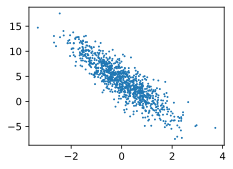

In [74]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach(),labels.detach().numpy(),1);

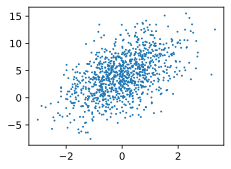

In [94]:
d2l.set_figsize()
d2l.plt.scatter(features[:,0].detach(),labels.detach().numpy(),1);

In [137]:
def data_iter(bactch_size,features,labels):
    num_examples = len(features)
    print(num_examples)
    indices = list (range(num_examples))
    random.shuffle(indices)
    #print(indices)
    for i in range(0,num_examples,batch_size): 
        batch_indices = torch.tensor(
            indices[i:min(i+batch_size, num_examples)])
        print('当前批次编号：',batch_indices)
        print("当前批次编号：",batch_indices)
        yield features [ batch_indices],labels[batch_indices]
        
batch_size = 10
for x,y in data_iter(batch_size,features, labels):
    print(x,'\n', y )
    
    break 


1000
当前批次编号： tensor([801, 333, 319, 487, 653, 486, 636, 775, 657, 869])
当前批次编号： tensor([801, 333, 319, 487, 653, 486, 636, 775, 657, 869])
tensor([[-1.8467,  0.0795],
        [-2.4156,  1.0518],
        [-0.8196, -1.1063],
        [ 0.2942, -1.5242],
        [ 1.7936, -0.8234],
        [ 1.0268, -0.5997],
        [ 0.1399, -0.5982],
        [ 1.1173,  0.5405],
        [ 0.7318, -0.5706],
        [ 0.0411, -0.2118]]) 
 tensor([[ 0.2295],
        [-4.2028],
        [ 6.3299],
        [ 9.9647],
        [10.6026],
        [ 8.3034],
        [ 6.5162],
        [ 4.6037],
        [ 7.6096],
        [ 5.0094]])


In [138]:
w = torch.normal(0,0.01,size=(2,1),requires_grad = True ) 
#给我生成两个初始权重， 把它们放成2*1的矩阵并且告诉pytorch 这两个权重以后需要计算梯度，需要学习
# 按照均值为0 标准差为0.01的正态分布，随机初始化一个形状为2，1的权重tensor 
#我要生成一个两行1列的tensor w =
#[  #我们有两个特征， 所以需要2个权重， 最终每个人只产生一个预测值 
# [ 0.0081],
# [-0.0047]
#]  为什么要两行1列，是因为我们矩阵乘法需要中间两个相同 我们和原来的两个特征相乘得到一个预测值
print(w)
b = torch.zeros(1,requires_grad =True) 
#给我一个初始值， 并且这个偏置以后也要学习
#创建要给长度为1的tensor , 并且里面的值都死0 
print(b)  #b = [0.] 就是初始化b= 0 

# requires_grad = true 是什么 告诉pytorch 这个tensor 是需要学习的参数， 请帮我记录它的计算过程， 并且在
#backward() 时计算它的梯度 告诉pytorch w和b是我要训练 ，我要让它们不断学习的东西
# 之后的 l.sun().backward() pytorch就会计算w.grad 。b.grad 
#然后SGD :w -= lr*w.grad   B -= lr * b.grad 

tensor([[-0.0007],
        [ 0.0124]], requires_grad=True)
tensor([0.], requires_grad=True)


In [139]:
def linreg(X,w,b):  #linreg = linear regression )线性回归
    """线性回归模型"""
    return torch.matmul(X,w)+b
    #这里y_hat是预测出来的值 而真实的答案是labels 

In [140]:
pred = linreg(feature,w,b)  #这里我们的预测值就是我们下山的时间 所以是y_hat 
print(pred[:10])
print(pred.shape)

tensor([[ 0.0032],
        [ 0.0070],
        [ 0.0090],
        [ 0.0081],
        [-0.0011],
        [-0.0145],
        [-0.0114],
        [ 0.0047],
        [ 0.0115],
        [ 0.0154]], grad_fn=<SliceBackward0>)
torch.Size([1000, 1])


In [144]:
def squared_loss(y_hat,y):  #所以这里是把所有人的损失都算出来
    """均方损失"""
    return(y_hat - y.reshape(y_hat.shape))**2/2 #把y的形状调整成y_hat一样
    #平方是为了放大误差， 以及纠正正负， /2是为了方便求导
    #它返回的是没要给样本的损失值， （y_hat -y) ^2 /2  tensor 不是一个数字而是一组数字

In [147]:
lossvalue = squared_loss(pred,labels)
print(lossvalue[:10])

tensor([[14.2697],
        [71.9825],
        [ 0.2324],
        [15.6319],
        [22.7883],
        [ 0.1765],
        [ 0.5204],
        [ 3.0512],
        [29.0231],
        [12.4001]], grad_fn=<SliceBackward0>)


In [148]:
y_hat = torch.tensor([[12.0],
                      [8.0],
                      [14.0]])

y = torch.tensor([[10.0],
                  [10.0],
                  [10.0]])

loss = squared_loss(y_hat, y)

print(loss)


tensor([[2.],
        [2.],
        [8.]])


In [149]:
def sgd(params,lr,batch_size):   #stochastic Gradient descent 随机梯度下降 sgd([w, b], lr, batch_size)
    """小批量随机梯度下降"""  #这里的params 是指一个python 列表，也就是 [w,b] 所以这里params 
    #可以理解成把所有需要学习的东西装进一个盒子里交给 sgd 以后的神经网络有可能， [w1, b1, w2, b2, ...]
    #lr =0.03  对lr learning rate = 学习率在 你每次下山走多大一步 lr 很小一步一步的慢慢走比较稳定， 
    #lr 很大，可能一步跨过了最低点所以每次根据梯度调整时， 步子的大小时0.03这个级别的
    #batch_size = 10 是每一批次我们拿多少样本
    with torch.no_grad():   #不要记录下面的参数修改过程
        #“接下来我要手动改参数，你别把这个修改过程也记录进自动求导系统。”
        for param in params:  #把w、b一个一个的拿出来 每循环一次就把里面的元素取出来一次交给params
            #所以 for 本身就是 Python 用来依次遍历一个可迭代对象的语法。
            #params=[w,b] 所以这个循环会 第一次param = w 第二次 param = b
            # 把w和b一个一个的拿出来处理。
            param -= lr*param.grad/batch_size  
            #l.sum().backward() 已经计算了梯度所以， w.grad 是loss对w的梯度 而b.grad loss对b的梯度
            #根据这一批10个人产生的平均坡度，让参数往下山方向走一步。
            #“参数减掉一小步梯度。” l.sum().backward()是吧这批次的10个人的损失加起来， 希望获得样本的平均梯度
            #10个人的梯度总和/10 平均梯度
            #所以param.grad 就是当前这个参数对应的梯度
            # w.grad = +5 w增大， 会让loss往上走  梯度是正参数往小了调
            # w.grad = -5 w增大 反而让loss下降   梯度是负参数往大调
            #所以核心就是参数减去梯度  \(参数 = 参数 - 学习率 \times 梯度\)
            param.grad.zero_() 
            #直接把 param.grad 里面的数据改成0。
            #为什么要清零，应为pytorch默认梯度是累积的 w.grad = 5 新的梯度 = 3  5 + 3 = 8、
            #计算梯度，使用梯度更新参数， 清零梯度， 下一批重新计算

In [100]:
lr = 0.03
num_epochs = 3
net = linreg 
loss = squared_loss

for epoch in range (num_epochs):  #num_epochs 是“我要循环几次”，epoch 是“我现在正在第几次”。
    for X,y in data_iter(batch_size,features,labels): #从我们之前写的 data_iter() 中，一批一批拿出 features 和 labels。
        l = loss(net(X,w,b),y)  #这一批10个人各自的损失。
        l.sum().backward()  #把这个批次所有损失加起来。对这个总损失进行反向传播，计算 w 和 b 的梯度。结果会出现 w.grad b.grad
        sgd([w,b],lr,batch_size) #根据 w.grad 更新 w  参数减去“学习率 × 这一批的平均梯度”，从而往下降方向走一步。
        with torch.no_grad():  # 训练完这一轮以后，用当前最新的 w、b，把全部1000个数据重新跑一遍，看看现在模型到底有多好了。
            train_l = loss(net(features,w,b) ,labels)
    print(f'epoch{epoch + 1 } ,loss {float(train_l.mean()):f}')
            #先求1000个人的平均损失，再把这个 Tensor 里的单个数取出来，方便打印。

epoch1 ,loss 0.043829
epoch2 ,loss 0.000164
epoch3 ,loss 0.000045


In [101]:
print ( f'w的估计误差：{true_w-w.reshape(true_w.shape)}')
print ( f'b的估计误差：{true_b - b }')

w的估计误差：tensor([-0.0002, -0.0015], grad_fn=<SubBackward0>)
b的估计误差：tensor([0.0010], grad_fn=<RsubBackward1>)


In [2]:
import os 
print (os.getcwd())

/home/jorin/deep_learning
